In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [41]:
df = pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [42]:
df.shape

(614, 13)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [44]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [45]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [46]:
#Handling Categorical Missing Values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

In [47]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [48]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [49]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [50]:
df.drop('Loan_ID', axis=1, inplace=True)

In [51]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income'],
      dtype='object')

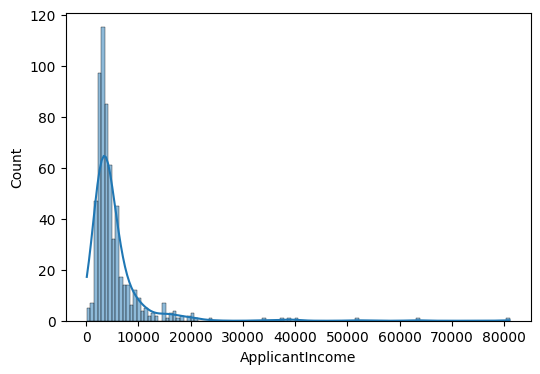

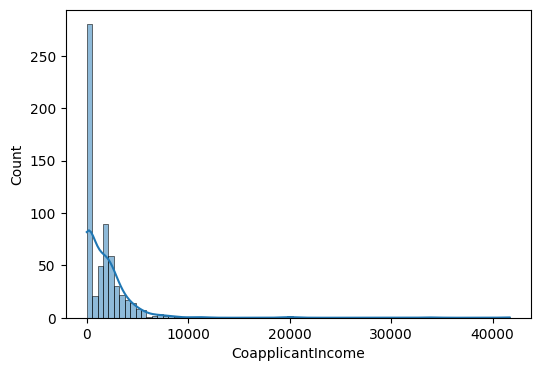

In [52]:
numeric_columns = ["ApplicantIncome","CoapplicantIncome"]
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True)

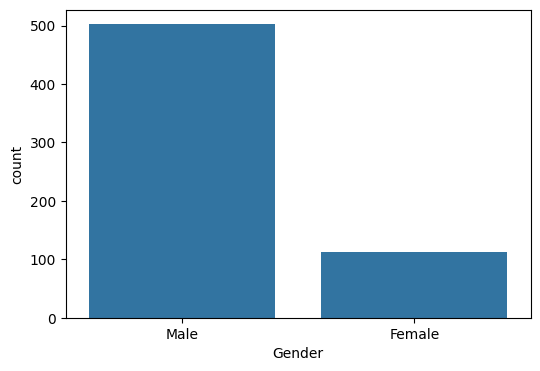

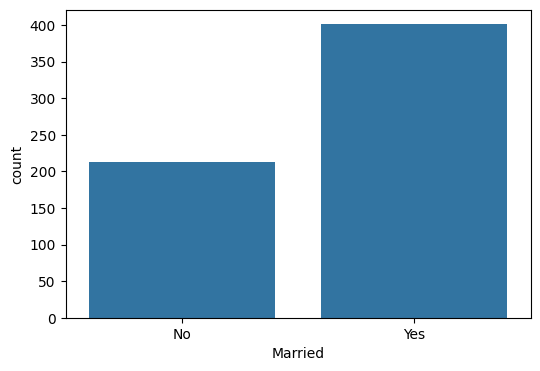

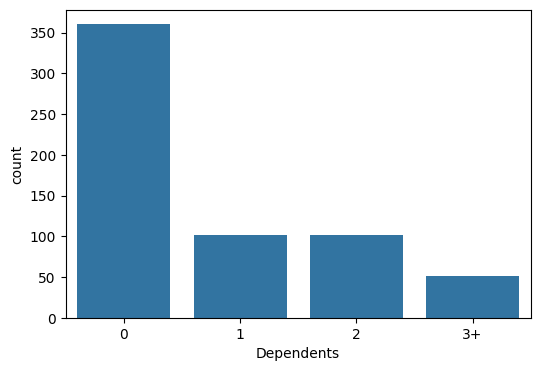

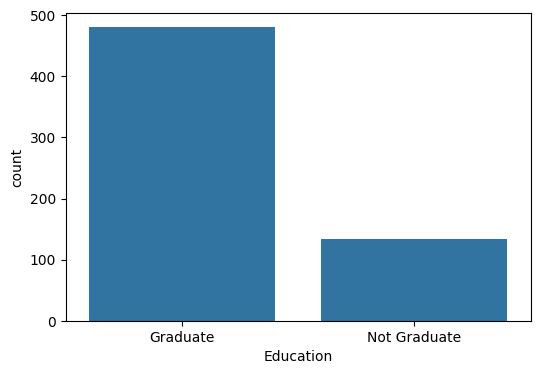

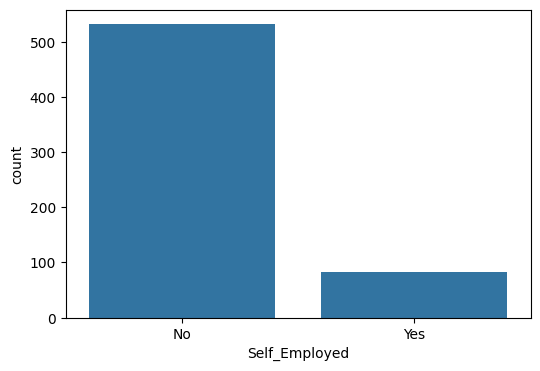

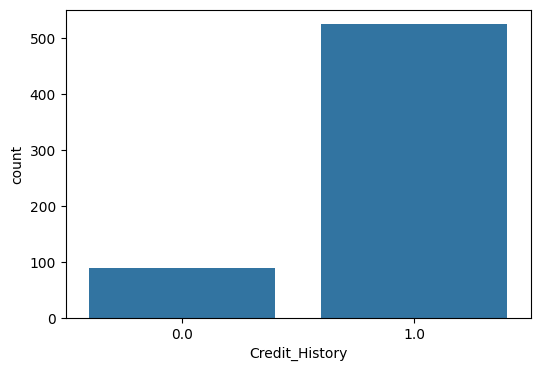

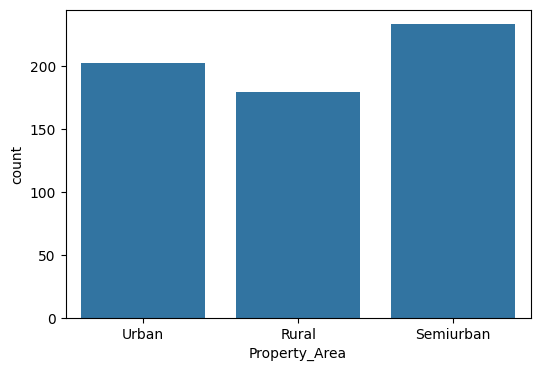

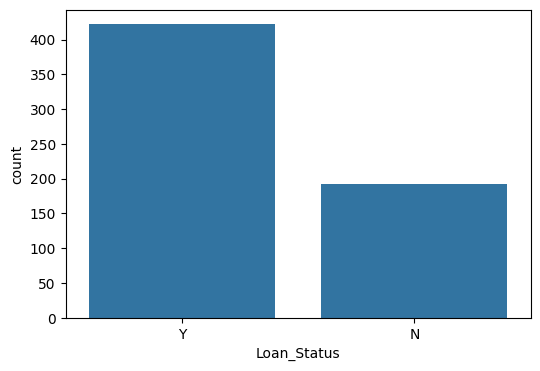

In [53]:
numeric_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Credit_History', 'Property_Area', 'Loan_Status',]
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])

<Axes: >

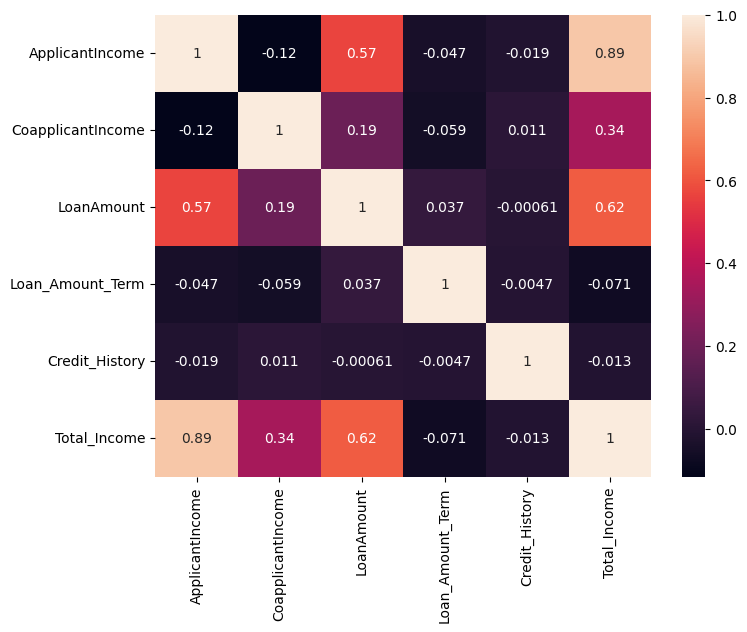

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [58]:
df = pd.get_dummies(df,columns = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status'],drop_first=True)

In [63]:
df["Dependents"]= df["Dependents"].replace('3+',3)

In [64]:
df = df.astype(int)

In [65]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,5849,0,128,360,1,5849,1,0,0,0,0,1,1
1,1,4583,1508,128,360,1,6091,1,1,0,0,0,0,0
2,0,3000,0,66,360,1,3000,1,1,0,1,0,1,1
3,0,2583,2358,120,360,1,4941,1,1,1,0,0,1,1
4,0,6000,0,141,360,1,6000,1,0,0,0,0,1,1


In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [68]:
from sklearn.preprocessing import StandardScaler
cols = ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income']
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

In [69]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,-0.737806,0.072991,-0.554487,-0.211241,360,1,-0.182184,1,0,0,0,0,1,1
1,0.253470,-0.134412,-0.038731,-0.211241,360,1,-0.144684,1,1,0,0,0,0,0
2,-0.737806,-0.393747,-0.554487,-0.948996,360,1,-0.623656,1,1,0,1,0,1,1
3,-0.737806,-0.462062,0.251980,-0.306435,360,1,-0.322884,1,1,1,0,0,1,1
4,-0.737806,0.097728,-0.554487,-0.056551,360,1,-0.158785,1,0,0,0,0,1,1


In [73]:
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [76]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_pred_lr = model_lr.predict(X_test)

In [89]:
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [79]:
ridge_model = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='liblinear'
)

ridge_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [88]:
y_pred_r = ridge_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_r)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_r))

Accuracy: 0.7642276422764228
              precision    recall  f1-score   support

           0       0.94      0.35      0.51        43
           1       0.74      0.99      0.84        80

    accuracy                           0.76       123
   macro avg       0.84      0.67      0.68       123
weighted avg       0.81      0.76      0.73       123



In [81]:
lasso_model = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='liblinear'
)

lasso_model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [87]:
y_pred_l = ridge_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_l)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_l))

Accuracy: 0.7642276422764228
              precision    recall  f1-score   support

           0       0.94      0.35      0.51        43
           1       0.74      0.99      0.84        80

    accuracy                           0.76       123
   macro avg       0.84      0.67      0.68       123
weighted avg       0.81      0.76      0.73       123

